# Week 6 
## AAPL Time-Series Analysis & Feature Engineering
**AnalystLab Africa | Data Analytics Track**

**Objective:** Apply advanced Pandas techniques for data transformation, time-series analysis, and feature engineering on Apple Inc. (AAPL) historical stock data.

**Deliverables checklist:**
- [ ] Data loading, exploration, cleaning
- [ ] Data transformation (Pandas)
- [ ] Time-series analysis (rolling averages, % change, monthly performance)
- [ ] Feature engineering (price change, returns, volatility, +1 custom feature)
- [ ] 4+ visualizations
- [ ] Key findings & conclusions
- [ ] *(after this notebook)* 1-2 page insight summary report



## 1. Setup & Imports

In [1]:
!pip install yfinance --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Data Loading

In [2]:
ticker = "AAPL"

# 5 years of daily data — plenty for meaningful trend/rolling-average analysis
df = yf.download(ticker, period="5y", interval="1d")

# yfinance returns a DatetimeIndex named 'Date' with OHLCV columns
df.index.name = "Date"
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-08-23,146.02,146.49,144.25,144.66,60131800
2021-08-24,145.94,147.14,145.48,145.77,48606400
2021-08-25,144.71,146.62,144.16,146.12,58991300
2021-08-26,143.91,145.45,143.88,144.70,48597200
2021-08-27,144.94,145.09,143.21,143.85,55802400


In [3]:
df.columns = df.columns.get_level_values(0)

## 3. Data Exploration

In [5]:
print("Shape:", df.shape)
print()
df.info()


Shape: (1254, 5)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2021-08-23 to 2026-08-20
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1254 non-null   float64
 1   High    1254 non-null   float64
 2   Low     1254 non-null   float64
 3   Open    1254 non-null   float64
 4   Volume  1254 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [6]:
df.index

DatetimeIndex(['2021-08-23', '2021-08-24', '2021-08-25', '2021-08-26',
               '2021-08-27', '2021-08-30', '2021-08-31', '2021-09-01',
               '2021-09-02', '2021-09-03',
               ...
               '2026-08-07', '2026-08-10', '2026-08-11', '2026-08-12',
               '2026-08-13', '2026-08-14', '2026-08-17', '2026-08-18',
               '2026-08-19', '2026-08-20'],
              dtype='datetime64[ns]', name='Date', length=1254, freq=None)

In [7]:
df.describe()


Price,Close,High,Low,Open,Volume
count,"1,254.00","1,254.00","1,254.00","1,254.00","1,254.00"
mean,198.56,200.54,196.38,198.34,"64,450,488.60"
std,48.37,48.75,47.91,48.29,"28,605,902.56"
min,122.83,125.53,121.99,123.80,"17,910,600.00"
25%,160.99,162.57,158.61,160.24,"45,330,100.00"
50%,186.96,188.06,185.15,186.55,"56,022,900.00"
75%,230.77,232.23,227.81,230.16,"76,155,400.00"
max,339.79,344.27,337.06,339.74,"318,679,900.00"


In [8]:
df.isnull().sum()


Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## 4. Data Cleaning & Preprocessing

- Confirm chronological order (ascending by date)
- Check for and handle any duplicate index entries

In [9]:
# Ensure data is sorted chronologically
df = df.sort_index(ascending=True)


# Check for duplicate dates in the index
df.index.duplicated().sum()

np.int64(0)

## 5. Data Transformation with Pandas


- Add `Year` and `Month` columns extracted from the date index
- Group by Year/Month to get monthly average closing price (aggregation)
- Aggregate mean rolling Volume

In [10]:
# Extract Year and Month from the index
df['Year'] = df.index.year
df['Month'] = df.index.month


# Group by Year & Month, aggregate mean Close price
monthly_avg_close = df.groupby(['Year', 'Month'])['Close'].mean()

# Aggregate mean rolling Volume
df['Volume_MA_30'] = df['Volume'].rolling(window=30).mean()

## 6. Time-Series Analysis

- Daily percentage change in Close price
- 7-day and 30-day rolling averages of Close price
- Monthly resample + monthly return calculation
- Trend observation - AAPL moved from 144.54 to 316.83 USD over the ~5 year window, a gain of roughly 119%. With a daily return of ~1.77%, it was a gradual but with day-to-day swing to its current heights as noted in the observations

In [11]:
# Daily percentage change in closing price
df['Daily_Return_%'] = df['Close'].pct_change() * 100



In [12]:
#: 7-day and 30-day rolling averages
df['MA_7']  = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()



In [13]:
# Resample to monthly frequency, then calculate monthly % return
monthly_close = df['Close'].resample('ME').last()
monthly_return = monthly_close.pct_change() * 100



In [14]:
print(df['Close'].iloc[0],df['Close'].iloc[-1])

146.02281188964844 311.29998779296875


In [15]:
df['Daily_Return_%'].std()

1.767702986199805

In [16]:
pct_gain = (df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0] * 100
print(pct_gain)

113.18586032175759


## 7. Feature Engineering

Required features:
- Daily Price Change (absolute $ change)
- Percentage Price Change (done above as `Daily_Return_%`)
- Moving Averages (done above as `MA_7` / `MA_30`)
- Monthly Returns (done above)
- Volatility Measure
- Cumulative Return

In [17]:
# Daily Price Change (absolute)
df['Price_Change'] = df['Close'].diff()



In [18]:
# Volatility — rolling standard deviation of daily returns (30-day window)
df['Volatility_30'] = df['Daily_Return_%'].rolling(window=30).std()



In [19]:
# Cumulative return
df['Cumulative return'] = (1 + df['Daily_Return_%']/100).cumprod()


In [20]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Year', 'Month',
       'Volume_MA_30', 'Daily_Return_%', 'MA_7', 'MA_30', 'Price_Change',
       'Volatility_30', 'Cumulative return'],
      dtype='object', name='Price')


## 8. Visualizations 


1. Stock Closing Price Trend
2. Trading Volume Trend
3. Moving Average Analysis (Close + MA_7 + MA_30 overlay)
4. Daily or Monthly Returns Analysis
5. 30 Day Rolling Volatility Analysis
6. Trading Volume with 30-Day Moving Average


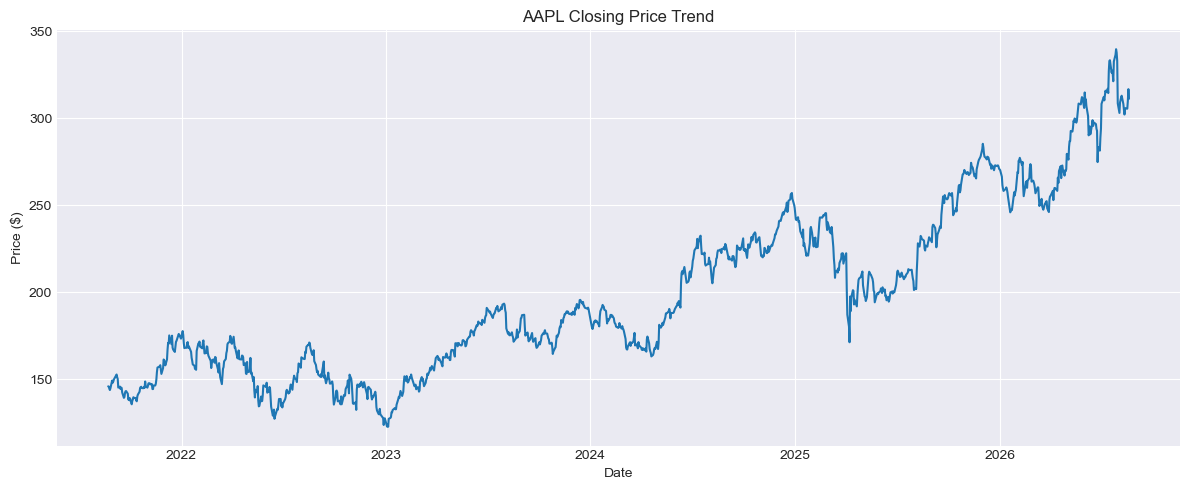

In [22]:
# Plot 1: Closing Price Trend
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'])

plt.title(f"{ticker} Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.savefig("visuals/closing_price_trend.png")
plt.show()


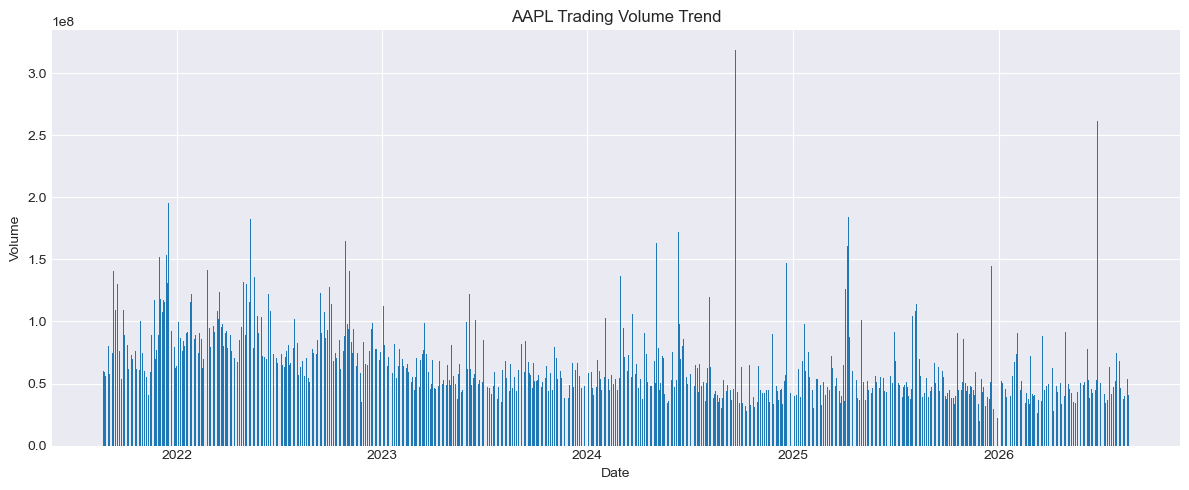

In [23]:
# Plot 2: Trading Volume Trend
plt.figure(figsize=(12, 5))
plt.bar(df.index, df['Volume'])

plt.title(f"{ticker} Trading Volume Trend")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.tight_layout()
plt.savefig("visuals/volume_trend.png")
plt.show()


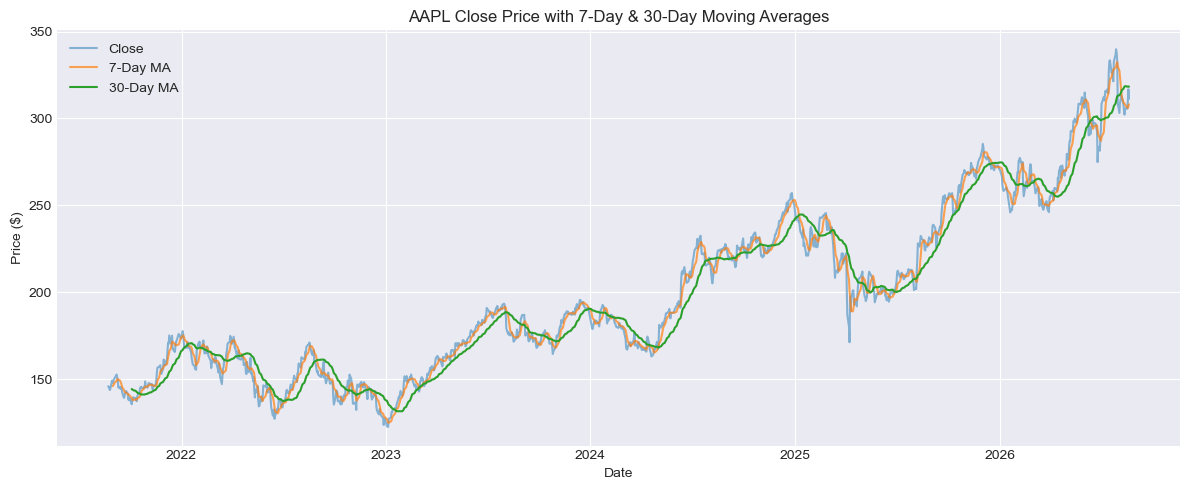

In [24]:
# Plot 3: Moving Average Analysis
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], label='Close', alpha=0.5)
plt.plot(df.index, df['MA_7'], label='7-Day MA', alpha=0.7)
plt.plot(df.index, df['MA_30'], label='30-Day MA', alpha=1)

plt.title(f"{ticker} Close Price with 7-Day & 30-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.tight_layout()
plt.savefig("visuals/moving_average_analysis")
plt.show()


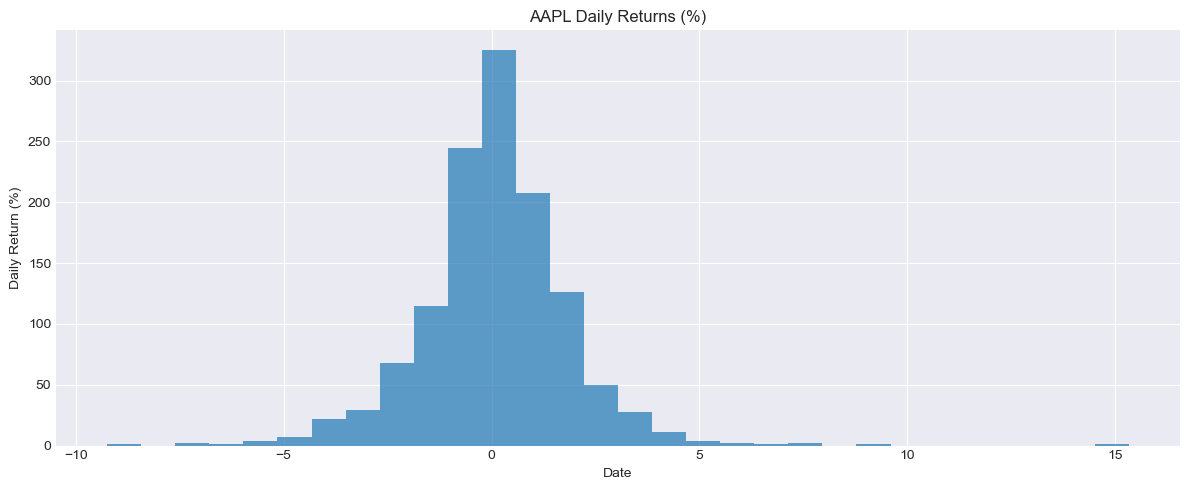

In [25]:
# Plot 4: Daily Returns Analysis
plt.figure(figsize=(12, 5))
plt.hist(df['Daily_Return_%'].dropna(), bins=30, alpha=0.7)

plt.title(f"{ticker} Daily Returns (%)")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.tight_layout()
plt.savefig("visuals/daily_returns_distribution.png")
plt.show()


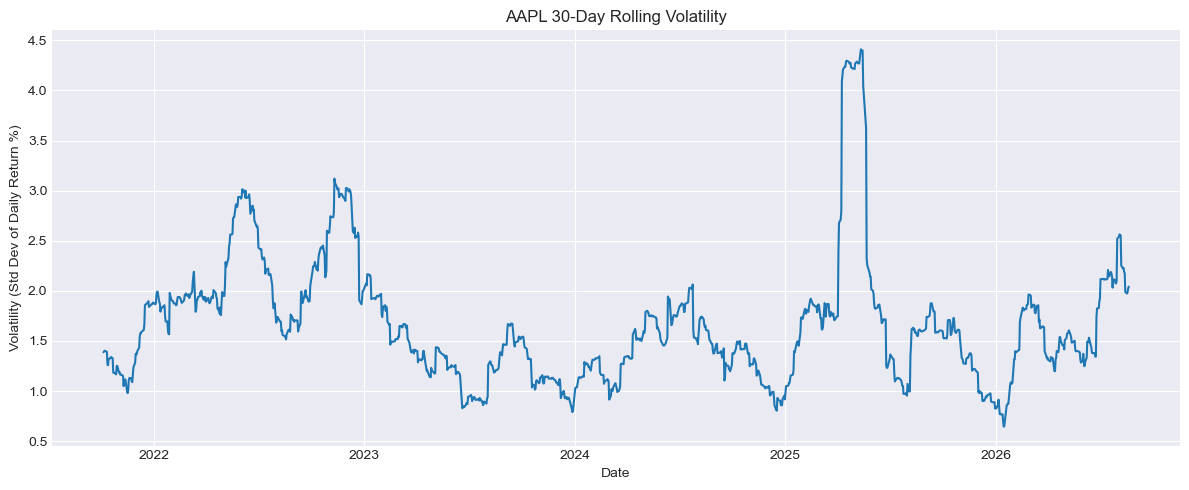

In [26]:
# Plot 5: 30 Day Rolling Volatility Analysis
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Volatility_30'])

plt.title(f"{ticker} 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (Std Dev of Daily Return %)")
plt.tight_layout()
plt.savefig("visuals/volatility_30.png")
plt.show()


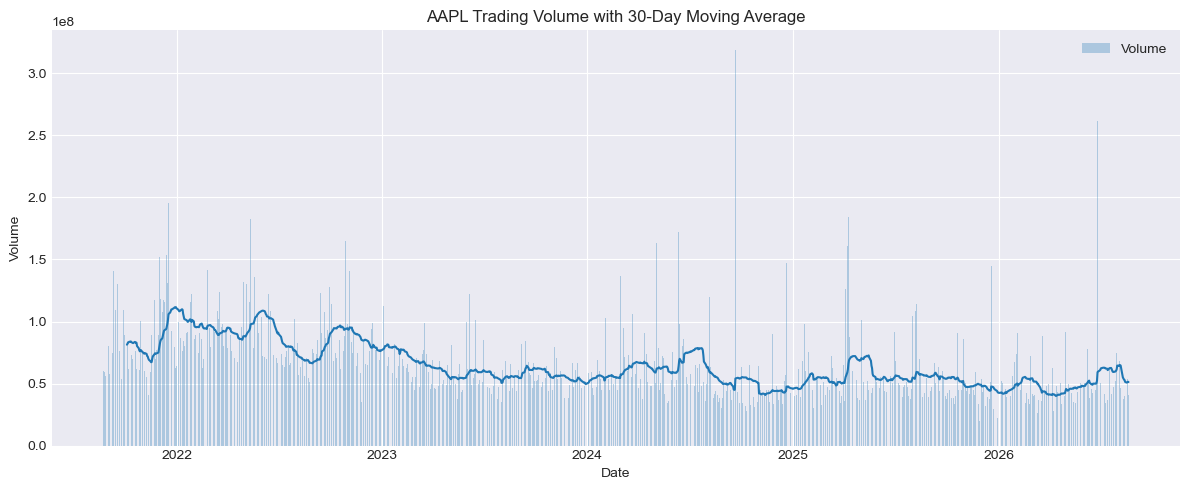

In [27]:
#Plot 6: Trading Volume with 30-Day Moving Average
plt.figure(figsize=(12,5))
plt.bar(df.index, df['Volume'], label='Volume', alpha=0.3)
plt.plot(df.index, df['Volume_MA_30'])

plt.title(f"{ticker} Trading Volume with 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.savefig("visuals/volume_with_ma30.png")
plt.show()

## 9. Key Findings & Conclusions

- Overall trend: AAPL rose from ~144.54 to ~316.83 USD over the 5-year window, a gain of roughly 119%, or about 2.2x. The climb wasn't linear: clear consolidation/pullback phases appear around 2022–2023 and again in 2024, before a stronger sustained run into 2025–2026.
- Moving averages: MA_7 tracks the daily Close closely and reacts fast to short-term swings, while MA_30 is much smoother and represents the underlying trend. Where MA_7 crosses above MA_30 (visible heading into each rally, e.g. late 2023 and again in 2025), it signals building short-term momentum; crossunders line up with the pullback periods.
- Volatility: Daily volatility (30-day rolling std of returns) mostly sat in a 1–2% range, but spiked sharply to ~4% around 2025; a clear outlier period worth flagging as the most turbulent stretch in the dataset.
- Volume: Trading volume stayed fairly range-bound with no strong long-term up/down trend, punctuated by periodic sharp spikes (likely earnings releases or major news days) rather than gradual buildup.
- Returns distribution: Daily returns cluster tightly around 0%, consistent with a typical stock; most days see small moves, with only a handful of larger outlier swings in either direction.
